In [10]:
import pandas as pd

data = pd.read_csv(r"C:\Users\b0316305\Desktop\data-science-project\dataset.csv")

data.head()

,Page Name,Day,Amount spent (PKR),Reporting starts,Reporting ends
0,censored,2025-06-10,479.85,2025-06-10,2025-06-10
1,censored,2025-06-09,2807.17,2025-06-09,2025-06-09
2,censored,2025-06-08,2051.74,2025-06-08,2025-06-08
3,censored,2025-06-07,2392.81,2025-06-07,2025-06-07
4,censored,2025-06-06,1279.79,2025-06-06,2025-06-06


In [11]:
data.shape

(135, 5)

In [12]:
data.columns

Index(['Page Name', 'Day', 'Amount spent (PKR)', 'Reporting starts',
       'Reporting ends'],
      dtype='object')

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Page Name           135 non-null    object 
 1   Day                 135 non-null    object 
 2   Amount spent (PKR)  135 non-null    float64
 3   Reporting starts    135 non-null    object 
 4   Reporting ends      135 non-null    object 
dtypes: float64(1), object(4)
memory usage: 5.4+ KB


In [14]:
data.describe()

,Amount spent (PKR)
count,135.000000
mean,2164.516889
std,1442.396621
min,78.400000
25%,843.160000
50%,2148.220000
75%,3028.140000
max,5410.610000


In [15]:
data.isnull().sum()

Page Name             0
Day                   0
Amount spent (PKR)    0
Reporting starts      0
Reporting ends        0
dtype: int64

In [16]:
data.shape
data.columns
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Page Name           135 non-null    object 
 1   Day                 135 non-null    object 
 2   Amount spent (PKR)  135 non-null    float64
 3   Reporting starts    135 non-null    object 
 4   Reporting ends      135 non-null    object 
dtypes: float64(1), object(4)
memory usage: 5.4+ KB


Page Name             0
Day                   0
Amount spent (PKR)    0
Reporting starts      0
Reporting ends        0
dtype: int64

In [18]:
data["Reporting starts"] = pd.to_datetime(data["Reporting starts"])
data["Reporting ends"] = pd.to_datetime(data["Reporting ends"])

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Page Name           135 non-null    object        
 1   Day                 135 non-null    object        
 2   Amount spent (PKR)  135 non-null    float64       
 3   Reporting starts    135 non-null    datetime64[ns]
 4   Reporting ends      135 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(1), object(2)
memory usage: 5.4+ KB


In [21]:
data["Amount spent (PKR)"].sum()

np.float64(292209.78)

In [22]:
data["Amount spent (PKR)"].mean()

np.float64(2164.5168888888893)

In [23]:
data.groupby("Day")["Amount spent (PKR)"].sum()

Day
2025-01-02    5226.56
2025-01-03    3944.00
2025-01-04    5235.33
2025-01-05    3194.40
2025-01-06    3020.42
               ...   
2025-06-06    1279.79
2025-06-07    2392.81
2025-06-08    2051.74
2025-06-09    2807.17
2025-06-10     479.85
Name: Amount spent (PKR), Length: 135, dtype: float64

In [24]:
data.loc[data["Amount spent (PKR)"].idxmax()]

Page Name                        censored
Day                            2025-03-22
Amount spent (PKR)                5410.61
Reporting starts      2025-03-22 00:00:00
Reporting ends        2025-03-22 00:00:00
Name: 62, dtype: object

In [25]:
data.groupby("Page Name")["Amount spent (PKR)"].sum().sort_values(ascending=False)

Page Name
censored    292209.78
Name: Amount spent (PKR), dtype: float64

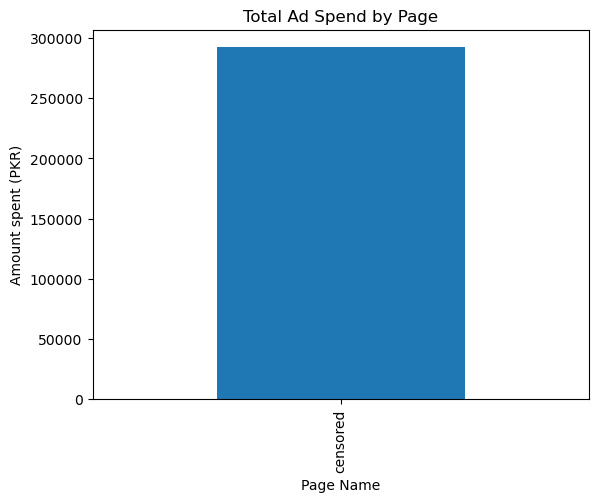

In [26]:
import matplotlib.pyplot as plt

data.groupby("Page Name")["Amount spent (PKR)"].sum().plot(kind="bar")

plt.title("Total Ad Spend by Page")
plt.ylabel("Amount spent (PKR)")
plt.xlabel("Page Name")

plt.show()

In [27]:
plt.savefig("ad_spend_by_page.png")

<Figure size 640x480 with 0 Axes>

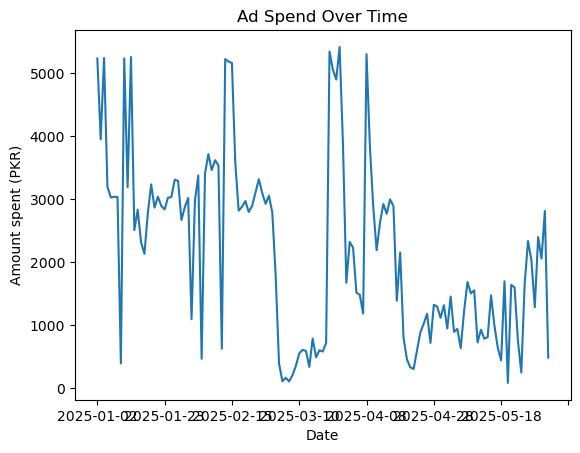

In [28]:
import matplotlib.pyplot as plt

data.groupby("Day")["Amount spent (PKR)"].sum().plot()

plt.title("Ad Spend Over Time")
plt.xlabel("Date")
plt.ylabel("Amount spent (PKR)")

plt.show()

In [29]:
plt.savefig("ad_spend_trend.png")

<Figure size 640x480 with 0 Axes>

In [30]:
data["Amount spent (PKR)"].mean()

np.float64(2164.5168888888893)

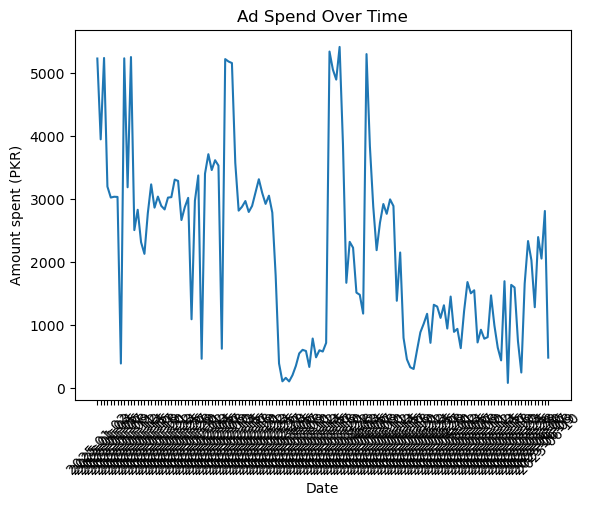

In [31]:
data = data.sort_values("Day")

plt.figure()

plt.plot(data["Day"], data["Amount spent (PKR)"])

plt.title("Ad Spend Over Time")
plt.xlabel("Date")
plt.ylabel("Amount spent (PKR)")

plt.xticks(rotation=45)

plt.show()

In [32]:
data.nlargest(5, "Amount spent (PKR)")

,Page Name,Day,Amount spent (PKR),Reporting starts,Reporting ends
62,censored,2025-03-22,5410.61,2025-03-22,2025-03-22
65,censored,2025-03-19,5337.14,2025-03-19,2025-03-19
54,censored,2025-04-08,5296.85,2025-04-08,2025-04-08
124,censored,2025-01-13,5250.00,2025-01-13,2025-01-13
132,censored,2025-01-04,5235.33,2025-01-04,2025-01-04


In [35]:
data["Day"] = pd.to_datetime(data["Day"])

In [36]:
data["Week"] = data["Day"].dt.isocalendar().week

data.groupby("Week")["Amount spent (PKR)"].mean()

Week
1     4400.072500
2     2980.466667
3     3002.325714
4     2995.204286
5     2648.235000
6     3076.794286
7     3948.088000
8     2963.072857
9     2725.044000
10     217.181667
11     561.681429
12    3663.605000
13    3864.470000
14    1839.574000
15    2987.211429
16    1916.632857
17     715.898571
18    1187.035714
19    1176.745714
20     863.052857
21    1148.158000
22    1563.205000
23    1908.113333
24    1643.510000
Name: Amount spent (PKR), dtype: float64

In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 135 entries, 134 to 0
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Page Name           135 non-null    object        
 1   Day                 135 non-null    datetime64[ns]
 2   Amount spent (PKR)  135 non-null    float64       
 3   Reporting starts    135 non-null    datetime64[ns]
 4   Reporting ends      135 non-null    datetime64[ns]
 5   Week                135 non-null    UInt32        
dtypes: UInt32(1), datetime64[ns](3), float64(1), object(1)
memory usage: 7.0+ KB


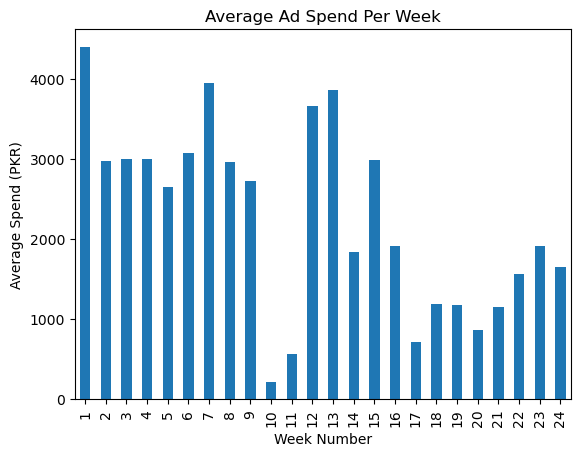

In [38]:
import matplotlib.pyplot as plt

weekly_spend = data.groupby("Week")["Amount spent (PKR)"].mean()

plt.figure()

weekly_spend.plot(kind="bar")

plt.title("Average Ad Spend Per Week")
plt.xlabel("Week Number")
plt.ylabel("Average Spend (PKR)")

plt.show()

In [39]:
plt.savefig("weekly_ad_spend.png")

<Figure size 640x480 with 0 Axes>

In [40]:
data["Day_of_Week"] = data["Day"].dt.day_name()

In [41]:
data.groupby("Day_of_Week")["Amount spent (PKR)"].mean().sort_values(ascending=False)

Day_of_Week
Saturday     2523.653158
Thursday     2402.917500
Wednesday    2268.041667
Friday       2230.637273
Sunday       1980.926842
Monday       1980.192632
Tuesday      1724.554444
Name: Amount spent (PKR), dtype: float64

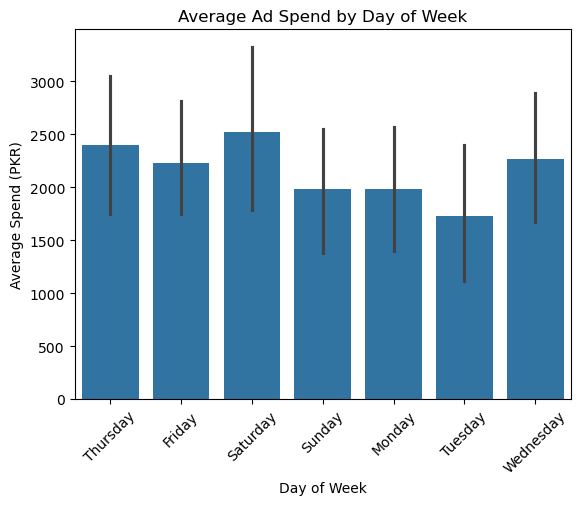

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.barplot(
    x=data["Day_of_Week"],
    y=data["Amount spent (PKR)"]
)

plt.title("Average Ad Spend by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Spend (PKR)")

plt.xticks(rotation=45)

plt.show()

In [43]:
plt.savefig("ad_spend_by_weekday.png")

<Figure size 640x480 with 0 Axes>